# Quickstart: ASTRO-TIGRESS

This is a concise introduction to pyathena, aimed mainly at new users.

Start by importing the necessary modules.

To use pyathena, add its directory to the `PYTHONPATH` environment variable in `.bashrc` or `.bash_profile`
```
export PYTHONPATH=/path/to/directory:$PYTHONPATH
```
Alternatively, you can dynamically add the path in your script or notebook.

In [1]:
import sys
sys.path.insert(0, '..')
import pyathena as pa

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

## LoadSim class

The `LoadSim` class is the primary interface for handling Athena/Athena++ simulation data.

Use the `help()` function to access documentation for the class:
```
help(pa.LoadSim)
```

**Pro Tip:** Use `class_or_func_name?`, `class_or_func_name??`, `help(class_or_func_name)`, or Shift+Tab in an interactive Python environment to view documentation, summaries, or source code.

### Initialization

- **Simulation Directory:** `LoadSim` uses the `basedir` parameter to locate all output files (`hst`, `hdf5`, `vtk`, etc.).


- **Save Directory:** The `savdir` parameter defines the directory for saving pickles and figures. If unspecified, it defaults to `basedir`.


- **Logger:** A logger is attached to the `LoadSim` instance print out log messages. The verbosity can be adjusted by setting **`verbose`** to `True` (equivalent `"INFO"`) or `False` (equivalent `"WARNING"`) or different levels of logging `"DEBUG"`, `"INFO"`, `"WARNING"`, `"ERROR"` (case insensitive). The default is set to `False`.


- **Metadata** : During the initialization, `FindFiles` class is initialized within `LoadSim` and it tries to find the athinput file and (e.g., `athinput.runtime`) or a file (e.g., `out.txt`) where standard output is redirected to. It then reads in simulations parameters and code configuration and saves results to a dictionary of dictionaries, **`par`**, containing all information. Other important metadata include information about the computational domain (**`domain`**), the date and time when code was configured (**`config_time`**).


- **Finding files** : Find output files based on the information available from par. The `find_files()` method can be called to find file names (**`files`**) and lists of snapshot numbers (**`nums*`**) again. File formats include
    * Athena-TIGRESS : `hst`, `sn`, `zprof`, `vtk`, `starpar_vtk`, `rst`, `timeit`
    * TIGRIS : `hst`, `sn`, `zprof`, `hdf5`, `rst`, `loop_time/task_time`

In [71]:
basedir = '/projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/'
s = pa.LoadSim(basedir, verbose=True)

[LoadSim-INFO] basedir: /projects/EOSTRIKE/TIGRESS_data_release/R8_2pc
[LoadSim-INFO] savdir: /projects/EOSTRIKE/TIGRESS_data_release/R8_2pc
[LoadSim-INFO] load_method: xarray
[FindFiles-INFO] athinput: /projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/input/MHD/R8_2pc.par
[FindFiles-INFO] athena_variant: Athena
[FindFiles-INFO] problem_id: R8_2pc_rst
[FindFiles-INFO] vtk (joined): /projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/0290/MHD nums: 290-390
[FindFiles-WARNING] starpar files not found in /projects/EOSTRIKE/TIGRESS_data_release/R8_2pc.
[FindFiles-INFO] timeit.txt not found.
[FindFiles-INFO] hst: /projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/history/MHD/R8_2pc.hst
[FindFiles-WARNING] sn file not found in {0:s}, but <feedback>/iSN=5
[FindFiles-WARNING] zprof files not found in /projects/EOSTRIKE/TIGRESS_data_release/R8_2pc
[FindFiles-WARNING] rst files in out_fmt but not found.


In [72]:
# files in MHD or MHD_PI were found and stored
print(s.files["vtk"][0])
print(s.files["vtk_pi"][0])

/projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/0290/MHD/R8_2pc.0290.vtk
/projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/0290/MHD_PI/R8_2pc.0290.vtk


### NOTE: temperature conversion is not properly handled in the pyathena for the data release VTK file

need to manually update the function to calculate temperature.

In [73]:
from pyathena.classic.cooling import coolftn
def _T(d, u):
    T1 = d['pressure']/d['density']*(u.velocity**2*ac.m_p/ac.k_B).cgs.value
    T1data = T1.data
    T1.data = coolftn().get_temp(T1data)
    return T1
s.dfi["T"]["field_dep"] = {'pressure','density'}
s.dfi["T"]["func"] = _T

### Attributes

Print some (read-only) attributes of a `LoadSim` instance.

In [74]:
s.basedir

'/projects/EOSTRIKE/TIGRESS_data_release/R8_2pc'

In [75]:
s.basename

'R8_2pc'

In [76]:
s.problem_id

'R8_2pc_rst'

`domain` contains information about simulation domain
- Nx: Number of cells
- le/re: left/right edge
- Lx: box size
- dx: cell size

In [77]:
s.domain

{'Nx': array([ 512,  512, 3584]),
 'ndim': 3,
 'le': array([ -512,  -512, -3584]),
 're': array([ 512,  512, 3584]),
 'Lx': array([1024, 1024, 7168]),
 'dx': array([2., 2., 2.]),
 'center': array([0., 0., 0.]),
 'time': None}

Date and time when the code is compiled

`par` contains all input parameters and meta information

In [78]:
s.par.keys()

dict_keys(['job', 'log', 'output1', 'output2', 'output3', 'output4', 'output5', 'output6', 'time', 'domain1', 'problem', 'feedback', 'configure'])

In [79]:
s.par['output2']

{'out_fmt': 'vtk',
 'out': 'prim',
 'dt': 1.0,
 'time': 322.0,
 'num': 322,
 'level': -1,
 'domain': -1,
 'id': 'out2'}

In [80]:
s.par['time']

{'grav_no': 1,
 'cour_no': 0.3,
 'nlim': -1,
 'tlim': 700.0,
 'time': 321.4286,
 'nstep': 124359}

In [81]:
s.par['problem']

{'gamma': 1.66666667,
 'surf': 12.0,
 'sz0': 10.0,
 'vturb': 10.0,
 'beta': 10,
 'Omega': 0.028,
 'qshear': 1.0,
 'SurfS': 42.0,
 'zstar': 245.0,
 'rhodm': 0.0064,
 'R0': 8000.0,
 'Sigma_SFR': 0.005,
 'rho_crit': 1.0}

Other attributes.

In [82]:
s.savdir

'/projects/EOSTRIKE/TIGRESS_data_release/R8_2pc'

In [83]:
s.load_method

'xarray'

### Finding files

**NOTE:** If `find_files()` did not succeed in finding output files under `basedir`, check if the glob patterns `s.ff.patterns` are set appropriately. Update it and try again. For example, the history dump is found using the glob patterns `/path_to_basedir/id0/*.hst` first. If it fails, it searches again with `/path_to_basedir/hst/*.hst`, and then with `/path_to_basedir/*.hst`

In [84]:
s.files.keys()

dict_keys(['athinput', 'vtk', 'vtk_pi', 'hst'])

In [85]:
s.files['vtk'][0], s.files['vtk'][-1]

('/projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/0290/MHD/R8_2pc.0290.vtk',
 '/projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/0390/MHD/R8_2pc.0390.vtk')

In [86]:
s.nums[0], s.nums[-1]

(290, 390)

In [87]:
type(s.ff)

pyathena.find_files.FindFiles

In [88]:
s.ff.patterns['hst']

[('history', 'MHD', '*.hst'), ('id0', '*.hst'), ('hst', '*.hst'), ('*.hst',)]

In [89]:
s.ff.patterns['vtk']

[('????', 'MHD', '*.????.vtk'), ('vtk', '*.????.vtk'), ('*.????.vtk',)]

## Units

Simulations run with Athena-TIGRESS/TIGRIS use the following code units

- TIGRESS-classic:

    - Mean particle mass per H: $\mu_{\rm H} = 1.4271$
    - $1\;{code\_density} \leftrightarrow n_{\rm H} = 1 {\rm cm}^{-3}$
    - Length : 1 pc
    - Velocity : 1 km/s
    

- TIGRESS-NCR:

    - Mean particle mass per H: $\mu_{\rm H} = 1.4$
    - $1\;{code\_density} \leftrightarrow n_{\rm H} = 1 {\rm cm}^{-3}$
    - Length : 1 pc
    - Velocity : 1 km/s
    

- TIGRIS with `"ism"` units:

    - Mean particle mass per H: $\mu_{\rm H} = 1.4$
    - $1.4\;{code\_density} \leftrightarrow \rho = 1.4 m_{\rm H}\;{\rm cm}^{-3} \leftrightarrow n_{\rm H} = 1 {\rm cm}^{-3}$
    - Length : 1 pc
    - Velocity : 1 km/s

In [90]:
u = s.u
# or
# u = pa.Units(kind='LV', muH=1.4)

Print code units (astropy Quantity)

In [91]:
type(s.u.time)

astropy.units.quantity.Quantity

In [92]:
s.u.time, s.u.mass, s.u.density, s.u.length, s.u.velocity, s.u.muH,

(<Quantity 3.08567758e+13 s>,
 <Quantity 0.03529472 solMass>,
 <Quantity 2.38871334e-24 g / cm3>,
 <Quantity 1. pc>,
 <Quantity 1. km / s>,
 1.4271)

In [93]:
s.u.energy, s.u.energy_density, s.u.momentum, s.u.momentum_flux

(<Quantity 7.01803729e+41 erg>,
 <Quantity 2.38871334e-14 erg / cm3>,
 <Quantity 0.03529472 km solMass / s>,
 <Quantity 0.03609634 km solMass / (s yr kpc2)>)

Commonly used astronomical constants and units (plain numbers). Multiply them to convert quantities in code units to one in physical units. For example,

- `(code mass)*u.Msun = mass in Msun`
- `(code time)*u.Myr = time in Myr`
- `(code luminosity)*u.Lsun = luminosity in Lsun`
- `(code pressure)*u.pok = P/k_B in cm^-3 K`

In [94]:
s.u.Msun, s.u.Myr, s.u.Lsun, s.u.pc,  s.u.kms, s.u.pok

(0.03529472163499891,
 0.9777922216807893,
 5.9414602654995275e-06,
 1.0,
 1.0,
 173.01380324473618)

## VTK dump

In [95]:
print(s.nums[0], s.nums[-1], len(s.nums)) # vtk file numbers in the directory

290 390 11


In [96]:
# use ivtk (index of pre-loaded vtk files; under MHD folder) rather than num to load files.
ds = s.load_vtk(ivtk=0)

[LoadSim-INFO] [load_vtk]: R8_2pc.0290.vtk. Time: 290.000200


In [97]:
ds.domain

{'all_grid_equal': True,
 'ngrid': 1,
 'le': array([-512., -512., -512.], dtype=float32),
 're': array([512., 512., 512.], dtype=float32),
 'dx': array([2., 2., 2.], dtype=float32),
 'Lx': array([1024., 1024., 1024.], dtype=float32),
 'center': array([0., 0., 0.], dtype=float32),
 'Nx': array([512, 512, 512]),
 'ndim': 3,
 'time': 290.0002}

In [98]:
# manual load (e.g., for MHD_PI file)
from pyathena.io.read_vtk import AthenaDataSet
ds = AthenaDataSet(s.files["vtk_pi"][0], units=s.u, dfi=s.dfi)

In [99]:
# note that the vertical extent for this output is bigger (original)
ds.domain

{'all_grid_equal': True,
 'ngrid': 1,
 'le': array([ -512.,  -512., -3584.], dtype=float32),
 're': array([ 512.,  512., 3584.], dtype=float32),
 'dx': array([2., 2., 2.], dtype=float32),
 'Lx': array([1024., 1024., 7168.], dtype=float32),
 'center': array([0., 0., 0.], dtype=float32),
 'Nx': array([ 512,  512, 3584]),
 'ndim': 3,
 'time': 290.0002}

Note that `domain['time']` is updated after reading loading a vtk file.

### Field names

The `field_list` contains all available variable names in vtk file, representing the raw data. The `derived_field_list` includes variables that are calculated based on those in the `field_list`, often expressed in more convenient units. Usually, fields in `derived_field_list` are in more convenient units.  When in doubt, it is recommended to use variables from the `field_list` and calculate derived quantities yourself.

In [100]:
print(ds.field_list)

['density', 'velocity', 'pressure', 'cell_centered_B', 'specific_scalar[0]']


In [101]:
print(ds.derived_field_list)

['rho', 'nH', 'pok', 'pok_trbz', 'r', 'vmag', 'vr', 'vx', 'vy', 'vz', 'cs', 'csound', 'Mr', 'Mr_abs', 'rhovr2ok', 'vAmag', 'vAx', 'Bx', 'vAy', 'By', 'vAz', 'Bz', 'Bmag', 'pok_mag', 'T', 'cool_rate_cgs', 'heat_rate_cgs', 'net_cool_rate', 'Lambda_cool', 'nHLambda_cool', 'nHLambda_cool_net', 'Gamma_heat', 't_cool', 'j_X']


In [102]:
ds.dirname, ds.ext

('/projects/EOSTRIKE/TIGRESS_data_release/R8_2pc/0290/MHD_PI', 'vtk')

### Read 3d data cubes

With ``xarray=True`` option (default is True), read dataset as a xarray DataSet.

See http://xarray.pydata.org/en/stable/quick-overview.html for a quick overview of xarray.

In [103]:
help(ds.get_field) # Note: setting (le, re) manually may not work as intended

Help on method get_field in module pyathena.io.read_vtk:

get_field(field='density', le=None, re=None, as_xarray=True) method of pyathena.io.read_vtk.AthenaDataSet instance
    Read 3d fields data.

    Parameters
    ----------
    field : (list of) string
        The name of the field(s) to be read.
    le : sequence of floats
       Left edge. Default value is the domain left edge.
    re : sequence of floats
       Right edge. Default value is the domain right edge.
    as_xarray : bool
       If True, returns results as an xarray Dataset. If False, returns a
       dictionary containing numpy arrays. Default value is True.

    Returns
    -------
    dat : xarray dataset
        An xarray dataset containing fields.



In [104]:
dat = ds.get_field(['nH', 'pok', 'T'])

Indexing follows the convention of the Athena code (k,j,i): for scalar fields, the innermost (fastest running) index is the x-direction, while the outermost index is the z-direction

In [105]:
dat['nH'].shape

(3584, 512, 512)

In [106]:
dat

<xarray.Dataset> Size: 11GB
Dimensions:  (x: 512, y: 512, z: 3584)
Coordinates:
  * x        (x) float64 4kB -511.0 -509.0 -507.0 -505.0 ... 507.0 509.0 511.0
  * y        (y) float64 4kB -511.0 -509.0 -507.0 -505.0 ... 507.0 509.0 511.0
  * z        (z) float64 29kB -3.583e+03 -3.581e+03 ... 3.581e+03 3.583e+03
Data variables:
    T        (z, y, x) float32 4GB 1.151e+06 1.155e+06 ... 1.776e+06 1.714e+06
    pok      (z, y, x) float32 4GB 203.6 202.5 201.7 201.0 ... 416.5 414.9 414.6
    nH       (z, y, x) float32 4GB 7.656e-05 7.59e-05 ... 0.0001011 0.0001047
Attributes:
    all_grid_equal:  True
    num:             290
    ngrid:           1
    le:              [ -512.  -512. -3584.]
    re:              [ 512.  512. 3584.]
    dx:              [2. 2. 2.]
    Lx:              [1024. 1024. 7168.]
    center:          [0. 0. 0.]
    Nx:              [ 512  512 3584]
    ndim:            3
    time:            290.0002
    dfi:             {'rho': {'field_dep': ['density'], 'func': <function set...

In [107]:
dat.x

<xarray.DataArray 'x' (x: 512)> Size: 4kB
array([-511., -509., -507., ...,  507.,  509.,  511.])
Coordinates:
  * x        (x) float64 4kB -511.0 -509.0 -507.0 -505.0 ... 507.0 509.0 511.0

Mean value of nH, pressure/kB at the midplane

In [108]:
dat.sel(z=0, method='nearest').mean()

<xarray.Dataset> Size: 32B
Dimensions:  ()
Coordinates:
    z        float64 8B 1.0
Data variables:
    T        float64 8B 2.582e+06
    pok      float64 8B 5.855e+03
    nH       float64 8B 0.6727

### Slice plots


- Use `dat.dfi` or `s.dfi` (derived field info) to set plot arguments
- See also https://docs.xarray.dev/en/latest/generated/xarray.plot.imshow.html

In [109]:
dat.dfi['nH']

{'field_dep': ['density'],
 'func': <function pyathena.fields.fields.set_derived_fields_def.<locals>._nH(d, u)>,
 'label': '$n_{\\rm H}\\;[{\\rm cm^{-3}}]$',
 'norm': <matplotlib.colors.LogNorm at 0x152b66d1f740>,
 'vminmax': (0.001, 10000.0),
 'cmap': 'Spectral_r',
 'scale': 'log',
 'take_log': True,
 'imshow_args': {'norm': <matplotlib.colors.LogNorm at 0x152b66d1f740>,
  'cmap': 'Spectral_r',
  'cbar_kwargs': {'label': '$n_{\\rm H}\\;[{\\rm cm^{-3}}]$'}}}

Text(0.5, 0.98, 'time=290.0002')

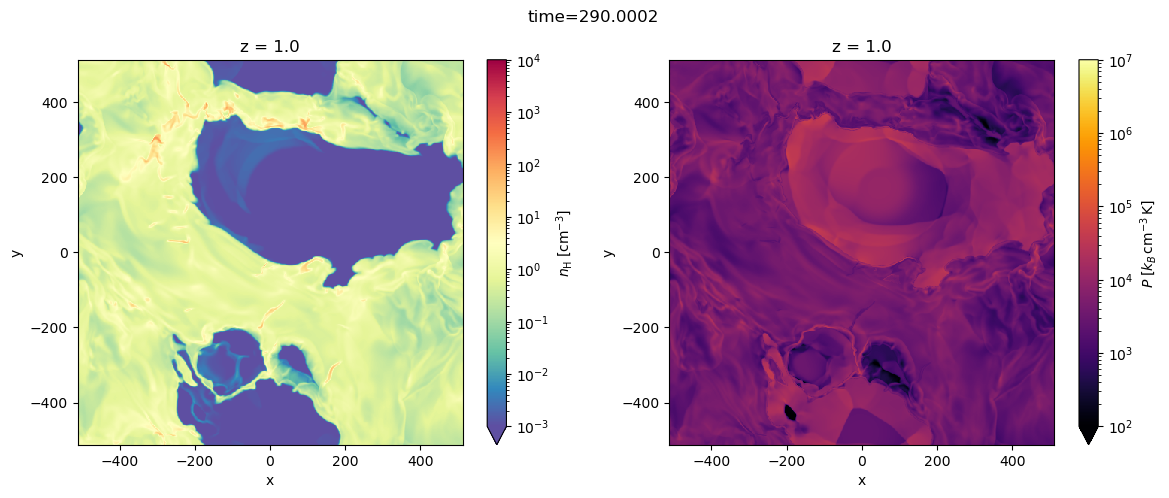

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dat['nH'].sel(z=0, method='nearest').plot.imshow(ax=axes[0], **dat.dfi['nH']['imshow_args'])
dat['pok'].sel(z=0, method='nearest').plot.imshow(ax=axes[1], **dat.dfi['pok']['imshow_args'])
plt.setp(axes, aspect='equal')
plt.suptitle(f'time={dat.time}')

Another example: plot slice of density and temperature at z=0

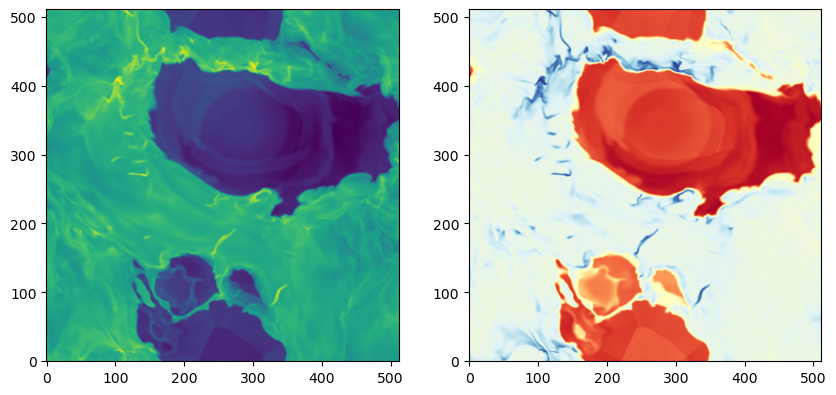

In [112]:
from pyathena.plt_tools.cmap_shift import cmap_shift
iz = ds.domain['Nx'][2] // 2
fig, axes = plt.subplots(1, 2, figsize=(10,5))
cmap_temp = cmap_shift(mpl.cm.RdYlBu_r, midpoint=3.0/7.0)
axes[0].imshow(d['nH'][iz,:,:], norm=LogNorm(), origin='lower')
axes[1].imshow(d['T'][iz,:,:], norm=LogNorm(), origin='lower',
               cmap=cmap_temp)

#### `get_slice()` method

In [113]:
help(ds.get_slice)

Help on method get_slice in module pyathena.io.read_vtk:

get_slice(axis, field='density', pos='c', method='nearest') method of pyathena.io.read_vtk.AthenaDataSet instance
    Read slice of fields.

    Parameters
    ----------
    axis : str
        Axis to slice along. 'x' or 'y' or 'z'
    field : (list of) str
        The name of the field(s) to be read.
    pos : float or str
        Slice through If 'c' or 'center', get a slice through the domain
        center. Default value is 'c'.
    method : str


    Returns
    -------
    slc : xarray dataset
        An xarray dataset containing slices.



In [114]:
slc = ds.get_slice('y', ['nH', 'T', 'pressure']) # x-z slices

In [115]:
slc

<xarray.Dataset> Size: 22MB
Dimensions:   (z: 3584, x: 512)
Coordinates:
  * x         (x) float64 4kB -511.0 -509.0 -507.0 -505.0 ... 507.0 509.0 511.0
    y         float64 8B 1.0
  * z         (z) float64 29kB -3.583e+03 -3.581e+03 ... 3.581e+03 3.583e+03
Data variables:
    pressure  (z, x) float32 7MB 1.171 1.162 1.152 1.143 ... 2.086 2.068 2.071
    T         (z, x) float32 7MB 1.289e+06 1.284e+06 ... 8.756e+05 8.74e+05
    nH        (z, x) float32 7MB 6.802e-05 6.777e-05 ... 0.0001769 0.0001775
Attributes:
    all_grid_equal:  True
    num:             290
    ngrid:           1
    le:              [ -512.  -512. -3584.]
    re:              [ 512.  512. 3584.]
    dx:              [2. 2. 2.]
    Lx:              [1024. 1024. 7168.]
    center:          [0. 0. 0.]
    Nx:              [ 512  512 3584]
    ndim:            3
    time:            290.0002
    dfi:             {'rho': {'field_dep': ['density'], 'func': <function set...

In [116]:
type(slc), type(slc.nH), type(slc.nH.data)

(xarray.core.dataset.Dataset, xarray.core.dataarray.DataArray, numpy.ndarray)

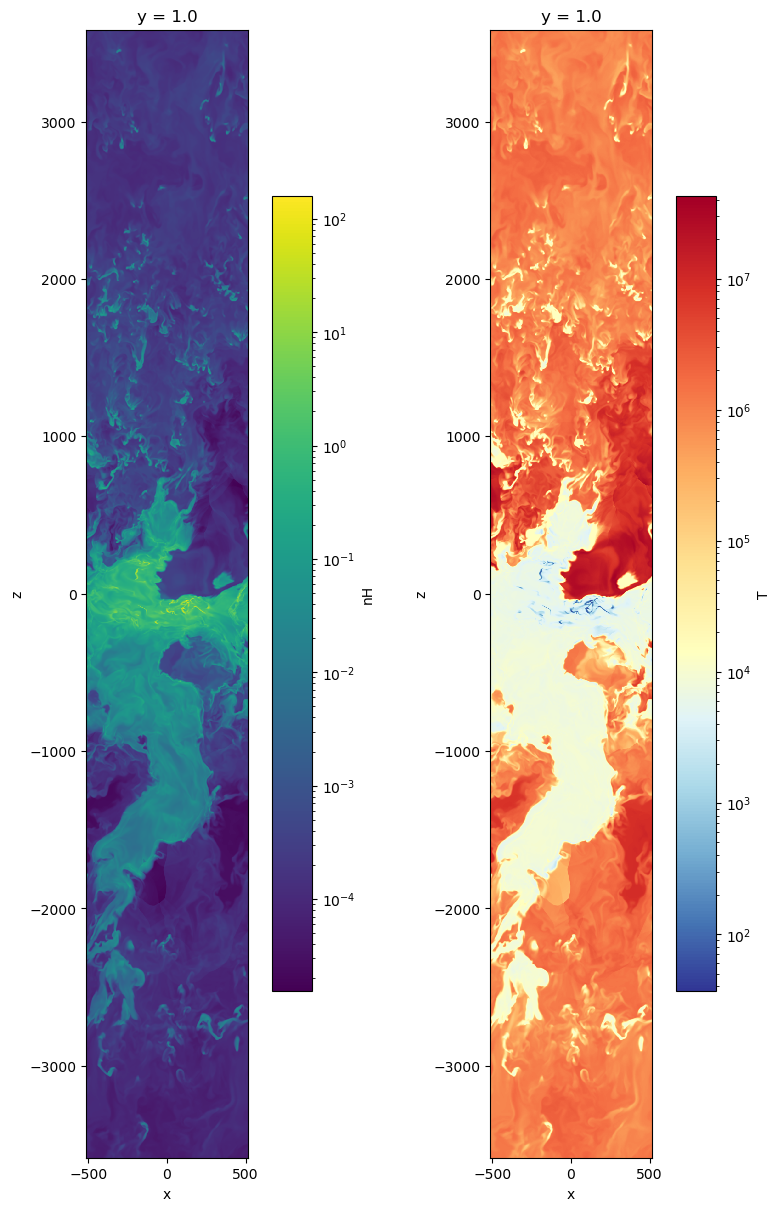

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(8, 12), constrained_layout=True)
im1 = slc['nH'].plot(ax=axes[0], norm=LogNorm())
im2 = slc['T'].plot(ax=axes[1], norm=LogNorm(), cmap=cmap_temp)
for im in (im1, im2):
    im.axes.set_aspect('equal')

## 2d histogram

In [ ]:
lognH = np.log10(dat['nH'].data.flatten())
logT = np.log10(dat['T'].data.flatten())
plt.hexbin(lognH, logT, mincnt=1, norm=mpl.colors.LogNorm())
plt.xlabel(r'$\log_{10}\,n_{\rm H}$')
plt.ylabel(r'$\log_{10}\,T$')

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
d = ds.get_field('rho')
conv_Sigma = (1.0*au.g/au.cm**2).to('Msun pc-2').value
dz_cgs = ds.domain['dx'][2]*u.length.cgs.value

(d['rho'].sum(dim='z')*dz_cgs*conv_Sigma).plot.imshow(ax=ax,
    cmap='pink_r', norm=mpl.colors.LogNorm(0.1, 2e2),
    cbar_kwargs=dict(label=r'$\Sigma_{\rm gas}\;[M_{\odot}\,{\rm pc}^{-2}]$'))
ax.set_aspect('equal')

## History dump

In [ ]:
# Read raw hst dump
h = pa.read_hst(s.files['hst']) # returns a pandas DataFrame object
h.columns

In [ ]:
h.head()

Plot

- timestep size `dt_mhd` (code unit)
- (total gas mass)/(volume of box) (code units)
- $\Sigma_{\rm SFR,40 Myr}$ (Msun/yr/kpc^2)

In [ ]:
ax = h.plot('time', y=['dt','mass', 'sfr40'])
ax.set_yscale('log')